In [47]:
import pandas as pd
import numpy as np
from shapely.geometry import Polygon, Point
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import geopandas as gpd
import contextily as cx
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import seaborn as sns

In [18]:
df_allDataFiltered = pd.read_csv('colombia_results_total_filtrado.csv')

In [19]:
df_allDataFiltered = df_allDataFiltered.drop(['Unnamed: 0', 'id', 'time'], axis=1)


In [32]:
# preprocessing data...

df_allDataFiltered = df_allDataFiltered[df_allDataFiltered['longitude'] >= -80]
df_allDataFiltered['longitude'] = df_allDataFiltered['longitude'].round(3)
df_allDataFiltered['latitude'] = df_allDataFiltered['latitude'].round(3)
df_allDataFiltered['coordinates'] = df_allDataFiltered.apply(lambda row: [row['longitude'], row['latitude']], axis=1)
df_allDataFiltered['date'] = pd.to_datetime(df_allDataFiltered['date'])
df_allDataFiltered

,longitude,latitude,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,date,coordinate_x,coordinate_y,coordinates,geometry,coordinates_tuple
0,-71.495,11.925,1862.269873,2019-02-08 12:02:12,[-71.495],[11.925],"[-71.495, 11.925]","POLYGON ((-71.5 11.92, -71.5 11.93000000000000...","(-71.495, 11.925)"
1,-71.745,11.915,1840.372803,2019-02-08 12:02:12,[-71.745],[11.915],"[-71.745, 11.915]","POLYGON ((-71.75 11.909999999999998, -71.75 11...","(-71.745, 11.915)"
2,-71.755,11.915,1840.372803,2019-02-08 12:02:12,[-71.755],[11.915],"[-71.755, 11.915]",POLYGON ((-71.75999999999999 11.90999999999999...,"(-71.755, 11.915)"
3,-71.765,11.915,1840.372803,2019-02-08 12:02:12,[-71.765],[11.915],"[-71.765, 11.915]","POLYGON ((-71.77 11.909999999999998, -71.77 11...","(-71.765, 11.915)"
4,-71.775,11.915,1840.372803,2019-02-08 12:02:12,[-71.775],[11.915],"[-71.775, 11.915]","POLYGON ((-71.78 11.909999999999998, -71.78 11...","(-71.775, 11.915)"
...,...,...,...,...,...,...,...,...,...
7266201,-72.435,4.525,1930.100098,2024-11-02 12:39:28,[-72.435],[4.525],"[-72.435, 4.525]","POLYGON ((-72.44 4.5200000000000005, -72.44 4....","(-72.435, 4.525)"
7266202,-72.445,4.525,1930.060781,2024-11-02 12:39:28,[-72.44500000000001],[4.525],"[-72.445, 4.525]","POLYGON ((-72.45 4.5200000000000005, -72.45 4....","(-72.445, 4.525)"
7266203,-72.455,4.525,1929.658248,2024-11-02 12:39:28,[-72.455],[4.525],"[-72.455, 4.525]","POLYGON ((-72.46 4.5200000000000005, -72.46 4....","(-72.455, 4.525)"
7266204,-72.255,4.525,1939.287932,2024-11-02 12:39:28,[-72.255],[4.525],"[-72.255, 4.525]",POLYGON ((-72.25999999999999 4.520000000000000...,"(-72.255, 4.525)"


In [33]:
df_clusteredMeanData = pd.read_csv('mean_values_clustered_v1.csv')

In [34]:
df_clusteredMeanData['coordinates'] = df_clusteredMeanData.apply(lambda row: [row['longitude'], row['latitude']], axis=1)

df_clusteredMeanData

,latitude,longitude,cluster,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,coordinates
0,10.005,-75.295,0,1927.416784,"[-75.295, 10.005]"
1,9.445,-74.565,0,1930.315294,"[-74.565, 9.445]"
2,6.255,-73.205,0,1900.766561,"[-73.205, 6.255]"
3,12.285,-71.575,0,1898.016579,"[-71.575, 12.285]"
4,7.915,-75.515,0,1905.816772,"[-75.515, 7.915]"
...,...,...,...,...,...
494241,3.105,-75.175,4,1916.644395,"[-75.175, 3.105]"
494242,4.175,-74.765,4,1913.924160,"[-74.765, 4.175]"
494243,2.565,-75.675,4,1873.410937,"[-75.675, 2.565]"
494244,2.885,-75.195,4,1931.592124,"[-75.195, 2.885]"


In [35]:
aa = np.sort(df_allDataFiltered['longitude'].unique())
np.shape(aa)

(1200,)

In [36]:
bb = np.sort(df_clusteredMeanData['longitude'].unique())
np.shape(bb)

(1200,)

In [37]:
# Find values in array1 that are not in array2
diff1 = np.setdiff1d(aa, bb)
print(len(diff1))
diff1


0


array([], dtype=float64)

In [38]:
latitude_difference = [-4.145, 12.435, 12.445]
longitude_difference = [-78.935, -78.925, -78.825, -78.485, -78.465, -78.455, -78.445, -77.875, -77.495]

# Filter rows where longitude is NOT in the longitude_difference list
df_allDataFiltered = df_allDataFiltered[~df_allDataFiltered['longitude'].isin(longitude_difference)]
df_allDataFiltered = df_allDataFiltered[~df_allDataFiltered['latitude'].isin(latitude_difference)]
df_allDataFiltered

,longitude,latitude,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,date,coordinate_x,coordinate_y,coordinates,geometry,coordinates_tuple
0,-71.495,11.925,1862.269873,2019-02-08 12:02:12,[-71.495],[11.925],"[-71.495, 11.925]","POLYGON ((-71.5 11.92, -71.5 11.93000000000000...","(-71.495, 11.925)"
1,-71.745,11.915,1840.372803,2019-02-08 12:02:12,[-71.745],[11.915],"[-71.745, 11.915]","POLYGON ((-71.75 11.909999999999998, -71.75 11...","(-71.745, 11.915)"
2,-71.755,11.915,1840.372803,2019-02-08 12:02:12,[-71.755],[11.915],"[-71.755, 11.915]",POLYGON ((-71.75999999999999 11.90999999999999...,"(-71.755, 11.915)"
3,-71.765,11.915,1840.372803,2019-02-08 12:02:12,[-71.765],[11.915],"[-71.765, 11.915]","POLYGON ((-71.77 11.909999999999998, -71.77 11...","(-71.765, 11.915)"
4,-71.775,11.915,1840.372803,2019-02-08 12:02:12,[-71.775],[11.915],"[-71.775, 11.915]","POLYGON ((-71.78 11.909999999999998, -71.78 11...","(-71.775, 11.915)"
...,...,...,...,...,...,...,...,...,...
7266201,-72.435,4.525,1930.100098,2024-11-02 12:39:28,[-72.435],[4.525],"[-72.435, 4.525]","POLYGON ((-72.44 4.5200000000000005, -72.44 4....","(-72.435, 4.525)"
7266202,-72.445,4.525,1930.060781,2024-11-02 12:39:28,[-72.44500000000001],[4.525],"[-72.445, 4.525]","POLYGON ((-72.45 4.5200000000000005, -72.45 4....","(-72.445, 4.525)"
7266203,-72.455,4.525,1929.658248,2024-11-02 12:39:28,[-72.455],[4.525],"[-72.455, 4.525]","POLYGON ((-72.46 4.5200000000000005, -72.46 4....","(-72.455, 4.525)"
7266204,-72.255,4.525,1939.287932,2024-11-02 12:39:28,[-72.255],[4.525],"[-72.255, 4.525]",POLYGON ((-72.25999999999999 4.520000000000000...,"(-72.255, 4.525)"


In [39]:
# se verifica que las coordenadas existentes sean las mismas en ambos datasets

lon_all_dataset = np.sort(df_allDataFiltered['longitude'].unique())
lat_all_dataset = np.sort(df_allDataFiltered['latitude'].unique())

lon_cluster_dataset = np.sort(df_clusteredMeanData['longitude'].unique())
lat_cluster_dataset = np.sort(df_clusteredMeanData['latitude'].unique())

bool_compare = np.array_equal(lon_all_dataset, lon_cluster_dataset) and np.array_equal(lat_all_dataset, lat_cluster_dataset)

print('Are the longitude coordinates the same for both datasets?',
      bool_compare)




Are the longitude coordinates the same for both datasets? True


In [42]:
# Select the the values corresponding to a specific value

def getClusterData(df_allValues, df_cluster, cluster):
    # Filter rows in df_cluster that belong to the specified cluster
    clusterData = df_cluster[df_cluster['cluster'] == cluster].copy()  # Explicitly create a copy
    
    # Convert the 'coordinates' column in both DataFrames to tuples (if they are lists)
    df_allValues['coordinates_tuple'] = df_allValues['coordinates'].apply(tuple)
    clusterData.loc[:, 'coordinates_tuple'] = clusterData['coordinates'].apply(tuple)  # Use .loc to avoid warning
    
    # Use .isin() to find matching rows
    matching_rows = df_allValues[df_allValues['coordinates_tuple'].isin(clusterData['coordinates_tuple'])].copy()  # Explicitly create a copy
    
    # Add the cluster column to the matching rows using .loc
    matching_rows.loc[:, 'cluster'] = np.full(len(matching_rows), cluster)
    
    # Drop the temporary 'coordinates_tuple' column
    matching_rows = matching_rows.drop(columns=['coordinates_tuple'])
    
    return matching_rows

In [43]:
cluster_0_all_data = getClusterData(df_allDataFiltered, df_clusteredMeanData, 0)

In [44]:
cluster_0_all_data

,longitude,latitude,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,date,coordinate_x,coordinate_y,coordinates,geometry,cluster
0,-71.495,11.925,1862.269873,2019-02-08 12:02:12,[-71.495],[11.925],"[-71.495, 11.925]","POLYGON ((-71.5 11.92, -71.5 11.93000000000000...",0
1,-71.745,11.915,1840.372803,2019-02-08 12:02:12,[-71.745],[11.915],"[-71.745, 11.915]","POLYGON ((-71.75 11.909999999999998, -71.75 11...",0
2,-71.755,11.915,1840.372803,2019-02-08 12:02:12,[-71.755],[11.915],"[-71.755, 11.915]",POLYGON ((-71.75999999999999 11.90999999999999...,0
3,-71.765,11.915,1840.372803,2019-02-08 12:02:12,[-71.765],[11.915],"[-71.765, 11.915]","POLYGON ((-71.77 11.909999999999998, -71.77 11...",0
4,-71.775,11.915,1840.372803,2019-02-08 12:02:12,[-71.775],[11.915],"[-71.775, 11.915]","POLYGON ((-71.78 11.909999999999998, -71.78 11...",0
...,...,...,...,...,...,...,...,...,...
7264035,-74.885,9.175,1943.948286,2024-10-27 12:52:54,[-74.885],[9.175],"[-74.885, 9.175]","POLYGON ((-74.89 9.17, -74.89 9.18000000000000...",0
7264036,-74.895,9.175,1942.193291,2024-10-27 12:52:54,[-74.895],[9.175],"[-74.895, 9.175]","POLYGON ((-74.89999999999999 9.17, -74.8999999...",0
7264040,-74.885,9.155,1943.948194,2024-10-27 12:52:54,[-74.885],[9.155],"[-74.885, 9.155]","POLYGON ((-74.89 9.149999999999999, -74.89 9.1...",0
7264041,-72.225,11.345,1944.442478,2024-10-27 12:52:54,[-72.22500000000001],[11.345],"[-72.225, 11.345]","POLYGON ((-72.23 11.34, -72.23 11.350000000000...",0


In [62]:

def getTimeSeriesPlot(df, title):
    # creating new columns with year, month and day values 
    #df['day'] = df['date'].dt.day
    #df['month'] = df['date'].dt.month
    #df['year'] = df['date'].dt.year
    
    # Create the plot
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df, x='date', y='CH4_column_volume_mixing_ratio_dry_air_bias_corrected', estimator='mean', errorbar=('ci', 95), err_style='band', color='black')
    
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('CH4 column volume mixing ratio dry air')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(True, which='major', linestyle='-', linewidth=0.5, color='gray', alpha=0.5)
    plt.grid(True, which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.2)
    plt.show()


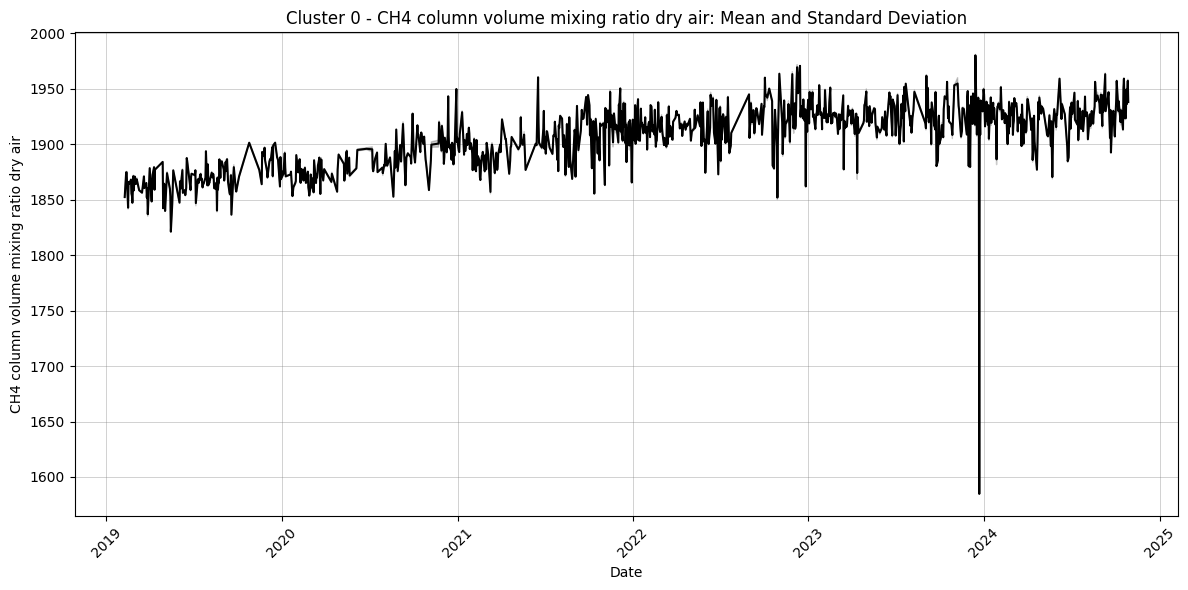

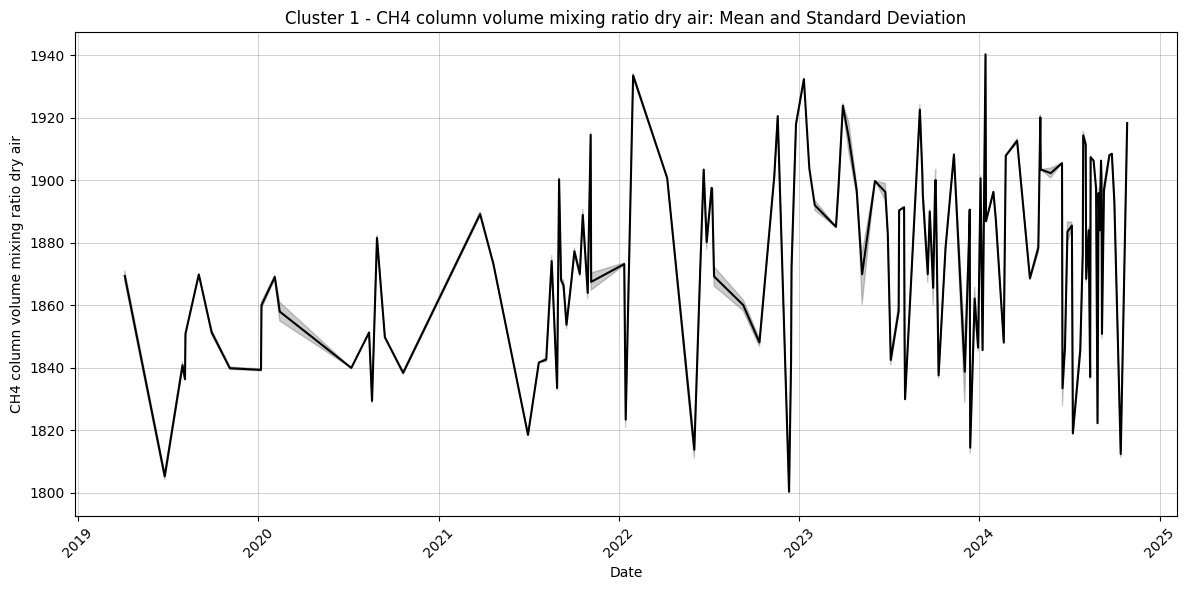

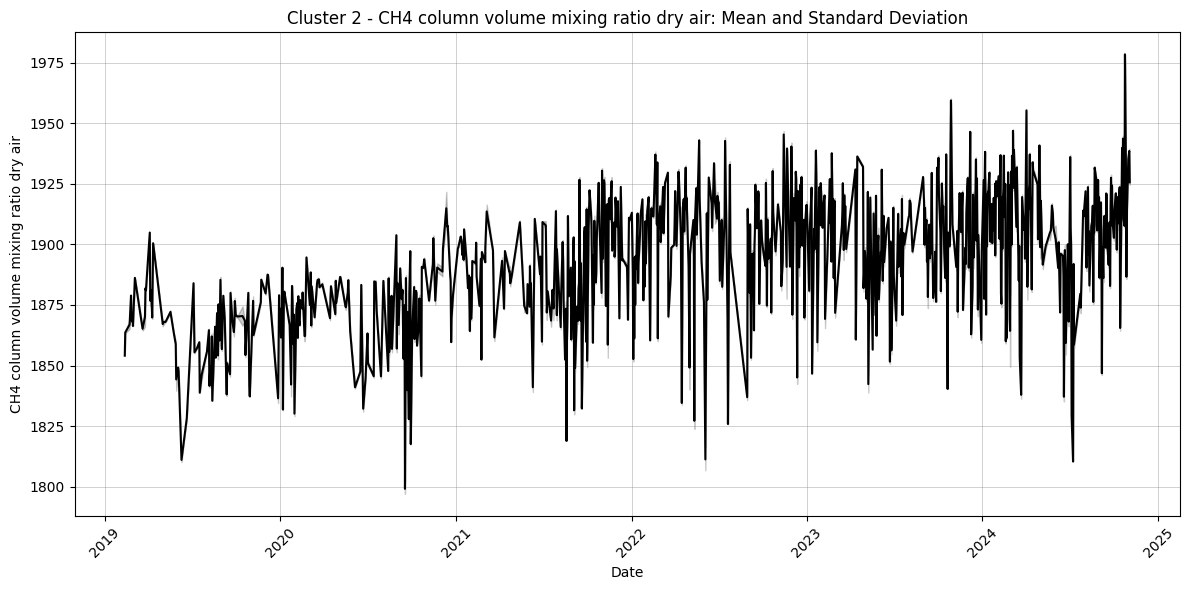

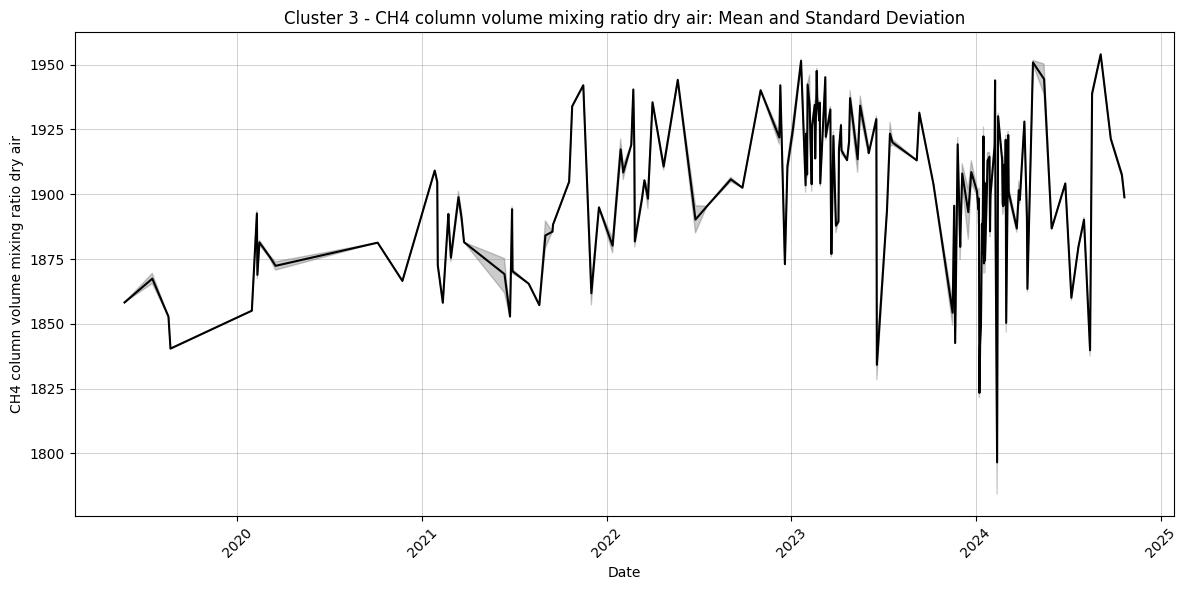

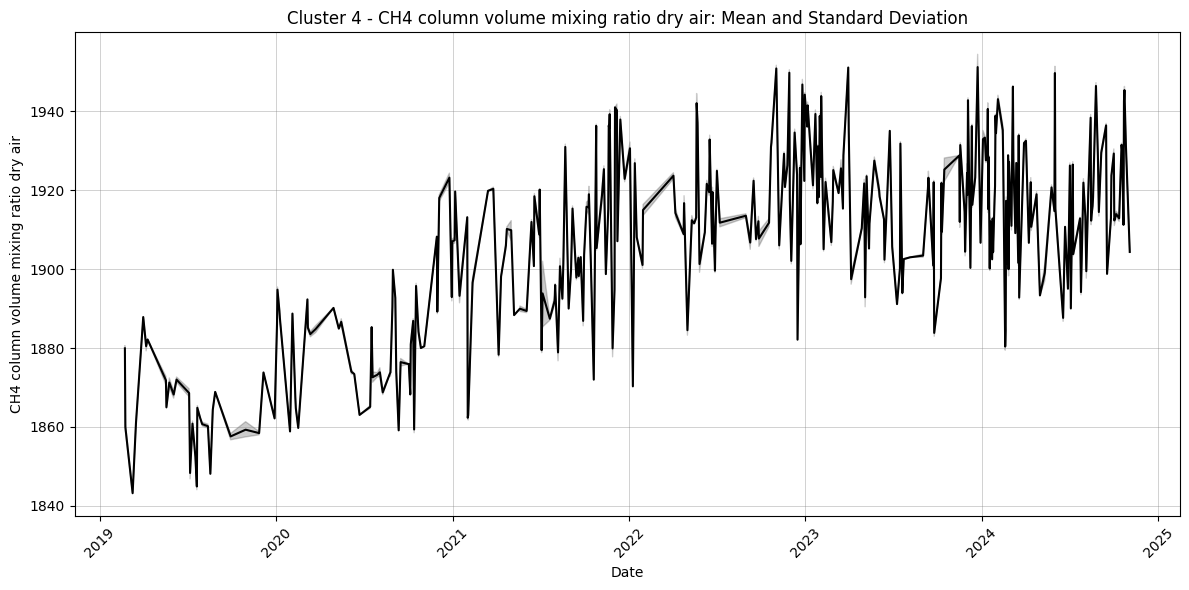

In [63]:
numberOfClusters = 5
for i in range(numberOfClusters):
    cluster_i_all_data = getClusterData(df_allDataFiltered, df_clusteredMeanData, i)
    title = 'Cluster ' + str(i) + ' - CH4 column volume mixing ratio dry air: Mean and Standard Deviation'
    getTimeSeriesPlot(cluster_i_all_data, title)

1
GeoDataFrame already has CRS: PROJCS["MAGNA-SIRGAS_2018_Origen-Nacional",GEOGCS["MAGNA-SIRGAS_2018",DATUM["Marco_Geocentrico_Nacional_de_Referencia_2018",SPHEROID["GRS_1980",6378137,298.257222101]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",4],PARAMETER["central_meridian",-73],PARAMETER["scale_factor",0.9992],PARAMETER["false_easting",5000000],PARAMETER["false_northing",2000000],UNIT["Meter",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


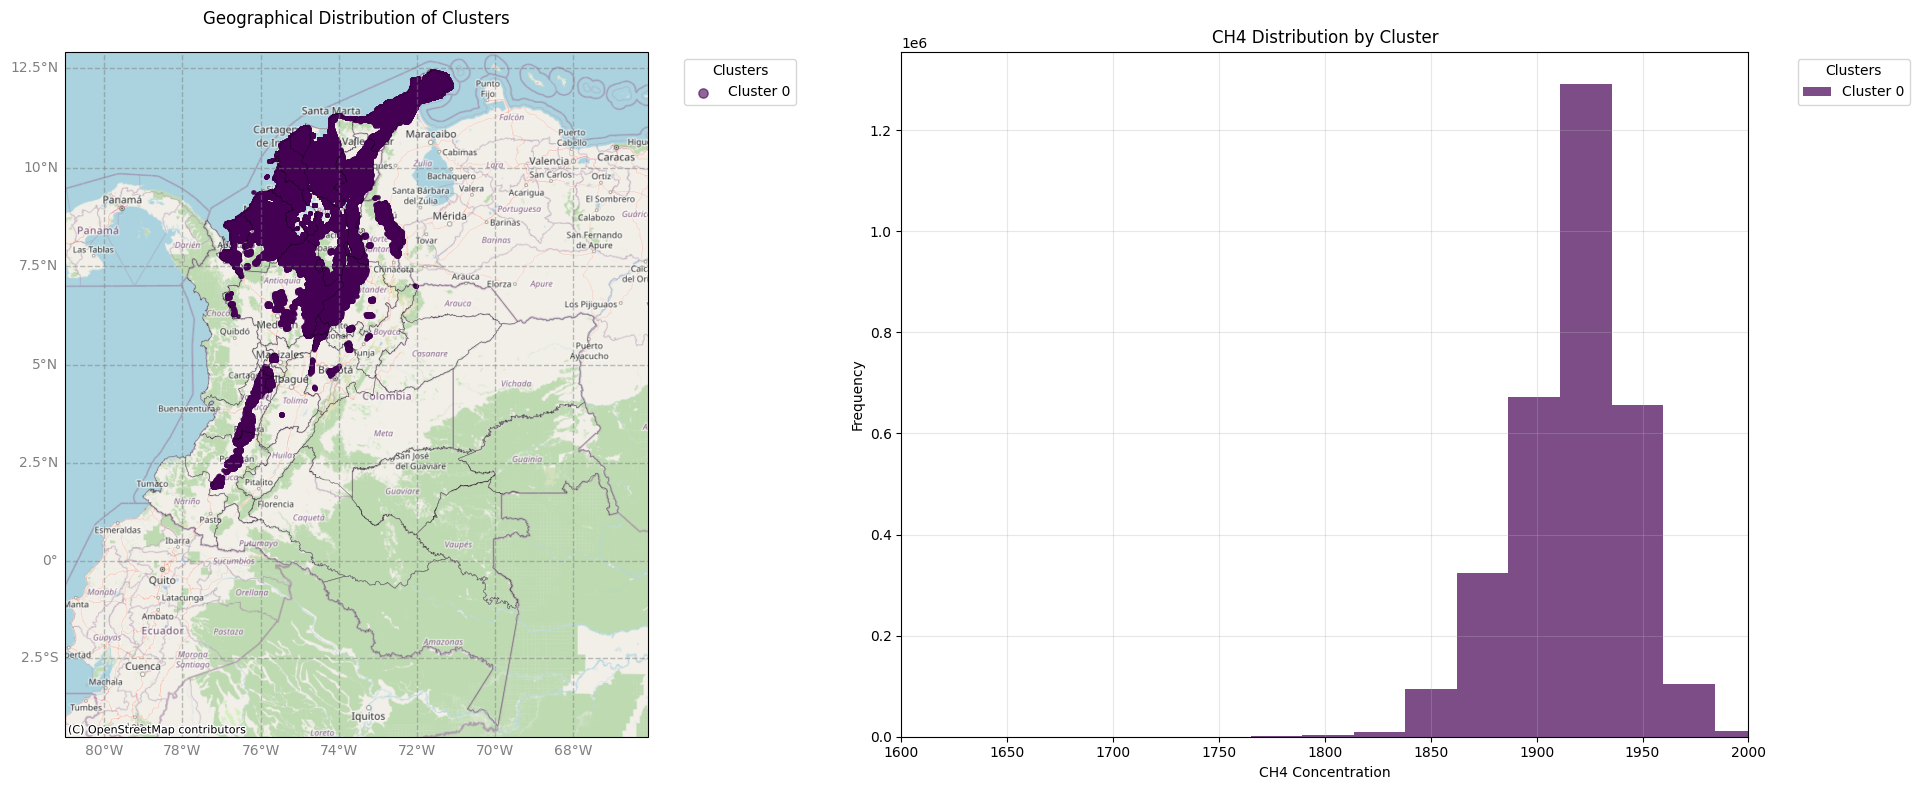


Cluster Statistics:
        CH4_column_volume_mixing_ratio_dry_air_bias_corrected                  \
                                                         mean    std    count   
cluster                                                                         
0                                                  1917.35     26.73  3166535   

        longitude latitude  
             mean     mean  
cluster                     
0          -73.68     9.87  


In [31]:
# Get the path to the file one directory up
# Get current working directory and go up one level
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
file_path = os.path.join(parent_dir, 'common/Departamentos_Junio_2024_shp/Departamento.shp')


# Load the file into a GeoDataFrame
gdf = gpd.read_file(file_path)

# Create figure and axes
fig = plt.figure(figsize=(20, 8))
gs = GridSpec(1, 2, figure=fig)

# First subplot - Map with clusters
ax1 = fig.add_subplot(gs[0], projection=ccrs.epsg(3857))

# Set map extent
extent = [-81, -66.1, -4.5, 12.9]
ax1.set_extent(extent, crs=ccrs.PlateCarree())

# Create GeoDataFrame from your clusters data
gdf_points = gpd.GeoDataFrame(
    cluster_0_all_data,
    geometry=gpd.points_from_xy(cluster_0_all_data.longitude, cluster_0_all_data.latitude),
    crs="EPSG:4326"
)

# Convert to web mercator for contextily basemap
gdf_points_mercator = gdf_points.to_crs(epsg=3857)

# Convertir la columna 'cluster' a enteros
gdf_points['cluster'] = gdf_points['cluster'].astype(int)

# Verificar los valores únicos después de la conversión
clusters = gdf_points['cluster'].unique()

print(len(clusters))
colors = plt.cm.viridis(np.linspace(0, 1, len(clusters)))

# Plot clusters on map with legend
for cluster, color in zip(clusters, colors):
    cluster_data = gdf_points[gdf_points['cluster'] == cluster]
    ax1.scatter(
        cluster_data.longitude,
        cluster_data.latitude,
        color=color,
        label=f'Cluster {cluster}',  # Add cluster number as label
        transform=ccrs.PlateCarree(),
        s=5,  # Marker size
        alpha=0.6
    )

# Add basemap 
cx.add_basemap(ax1, 
               source=cx.providers.OpenStreetMap.Mapnik)

# Add gridlines
gl = ax1.gridlines(crs=ccrs.PlateCarree(), 
                   draw_labels=True,
                   linewidth=1, 
                   color='gray', 
                   alpha=0.5, 
                   linestyle='--')

gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 10, 'color': 'gray'}
gl.ylabel_style = {'size': 10, 'color': 'gray'}

# Add colorbar to map
# cbar = plt.colorbar(scatter, ax=ax1)
# cbar.set_label('Cluster', fontsize=10)

# Add legend to map with larger points
legend = ax1.legend(
    title='Clusters', 
    loc='upper left', 
    bbox_to_anchor=(1.05, 1),
    markerscale=3  # Increase the size of points in the legend
)

# Adjust legend title font size
plt.setp(legend.get_title(), fontsize=10)



if gdf.crs is None:
    # Only set CRS if it doesn't have one
    gdf.set_crs(epsg=4326, inplace=True)
else:
    print("GeoDataFrame already has CRS:", gdf.crs)
gdf = gdf.to_crs(epsg=3857)
              
gdf.plot(ax=ax1, edgecolor='black', facecolor='none', linewidth=0.3, alpha=0.4)


# Add title to map
ax1.set_title('Geographical Distribution of Clusters', pad=20)





# Second subplot - Methane distribution
ax2 = fig.add_subplot(gs[1])
#colors = plt.cm.viridis(np.linspace(0, 1, optimal_k+2))  # Use same colormap as map

# color_f = np.zeros([5,4])
# color_f[0,:] = colors[1,:]
# color_f[1,:] = colors[2,:]
# color_f[2,:] = colors[0,:]
# color_f[3,:] = colors[4,:]
# color_f[4,:] = colors[3,:]


ax2.set_xlabel('CH4 Concentration')
ax2.set_ylabel('Frequency')
ax2.set_title('CH4 Distribution by Cluster')


for i in range(1):
    cluster_data = cluster_0_all_data[cluster_0_all_data['cluster'] == i]
    ax2.hist(cluster_0_all_data['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'], 
             alpha=0.7, 
             label=f'Cluster {i}',
             color=colors[i],  # Match colors with map
             bins=20)  # Adjust number of bins

# Add grid to histogram
ax2.grid(True, alpha=0.3)

# Customize histogram legend
ax2.legend(title='Clusters', 
          bbox_to_anchor=(1.05, 1), 
          loc='upper left')

ax2.set_xlim([1600, 2000])


# Adjust layout and save
plt.tight_layout()
plt.savefig('clusters.png', dpi=600, bbox_inches='tight')
plt.show()

# Print cluster statistics
print("\nCluster Statistics:")
print(cluster_0_all_data.groupby('cluster').agg({
    'CH4_column_volume_mixing_ratio_dry_air_bias_corrected': ['mean', 'std', 'count'],
    'longitude': 'mean',
    'latitude': 'mean'
}).round(2))